In [23]:
'''
This notebook uses the ray-tracing implemented by Pykonal (White et al., 2020) to calculate travel time and accumulated attenuation for source receiver pairs.
White, M. C. A., Fang, H., Nakata, N., & Ben-Zion, Y. (2020). PyKonal: A Python Package for Solving the Eikonal Equation in Spherical and Cartesian Coordinates Using the Fast Marching Method. Seismological Research Letters, 91(4), 2378-2389. https://doi.org/10.1785/0220190318

There are 3 major parts:
1. Read meta data including the catalog, the configuration, and the velocity model.
2. Calculate eikonal travel times (to all DAS channels) and save for one event. 
3. Calculate accumulated attenuation (to all DAS channels) and save for one event. 

The entire procedure from spectra to source parameters is (fX00 is the number of jupyter notebook in codes/. Open the .ipynb files using jupyterlab to see the 1.2.3. numbering of the sections in each notebook): 
(1) Prepare data: 
    a. Aligned P-wave spectra (spectra/)
    b. Event catalog (catalog/event_catalog.csv) 
    c. Arrival picks (catalog/arr_picks_P)
(2) (f300) Run 1 to load meta info.
(3) (f300) Run 2. repeatedly for all events to produce travel time and incident angle files (catalog/tt_inc_P).
(4) (f400) Run 1. to load meta info.
(5) (f400) Run 2. and 3. repeatedly for many suitable events to save channel-wise spectral ratio (save/decon_for_att) and measure Q (save/Q_profiles).
(6) (f400) Run 4. to save an average 1D Q profile (models/Q_profile_P_1OB_events_fit20-200Hz.npz) corresponsding to DAS channels.
(7) (f300) Run 1 to load meta info.
(8) (f300) Run 2. and 3. repeatedly for all events to produce accumulated attenuation files (catalog/accum_att_P).
(9) (f500) Run 1 to load meta info.
(10) (f500) Run 2. and 3. repeatedly for all events to calculate source parameters (fc, m0, source radius, slip, Mw, and spectral stress drop).
(11) Implement more QC procedures (e.g., incident angle, channels, std....) as appropriate.

The codes use the CC BY-NC 4.0 license, which allows for sharing and adapting material for non-commercial purposes only.

Hilary Chang 2026.3.24
hilarych@ldeo.columbia.edu

'''

import pandas as pd
from obspy.core import UTCDateTime
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from obspy.core import Stream, Trace
import sys
from copy import copy
from scipy.interpolate import interp1d
#sys.path.append('/home/hilarych/Forge_2024/')
import utils as ut
import utm
from scipy.signal import detrend
import scipy
import time
from datetime import datetime,timedelta
from matplotlib.gridspec import GridSpec
from obspy.signal.filter import bandpass
from mpl_toolkits.axes_grid1 import make_axes_locatable
from obspy.io.segy.core import _read_segy
import matplotlib as mpl
import lmfit 
import pykonal
from importlib import reload
reload(ut)
plt.rcParams['figure.dpi']=50

# For Silixa iDAS
sampleFrequency=1000.
gaugeLength=10.
conversionFactor    = 116.0 * 2**-13 * sampleFrequency / gaugeLength

# =============================================================================
# The main directory that host all data and results
# opda_dir='/mnt/data0/hilarych/FORGE_2024/save/open_data_Fervo' 
opda_dir='/global/scratch/projects/pc_aieqsim/nnakata/Cape/shared_tmp_data/'

# =============================================================================

# Read meta data

## Well location

In [24]:
#%% Well location
infile=os.path.join(opda_dir,'config','well_config.npz')
r=np.load(infile,allow_pickle=True)

ref_elev=r['ref_elev_m']
x_1OB=r['D_1OB_x_m']
y_1OB=r['D_1OB_y_m']
z_1OB=r['D_1OB_ele_m']
rec_list=np.arange(0,len(x_1OB),1) # Give each channel a number

## Velocity model

Horizontal distance between the well and the closest data point: 104.05845578271897 m


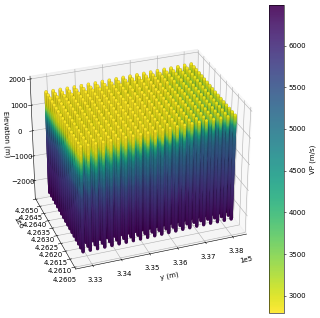

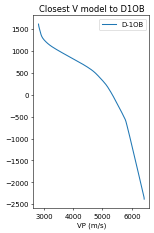

In [25]:
#%%% Velocity model
# =============================================================================
P_or_S='P'
# P_or_S='S'

# The Vp and Vs model (Forge3D_velo5D_float_01312018.sgy)seems to have an offset. I have to add these v discrepancies to match the observed arrivals.  
if P_or_S=='P':
    vp_discrepency=1200 # m/s # The Vp model seems to be 1.2 km/s slower than the obsered arrivals
elif P_or_S=='S':
    vp_discrepency=-1200 # m/s # I can match the S wave arrivals if I subtract 1.2 km/s from the Vp model
else:
    raise "P or S ???!!!"


plot_model=True
# Path of the velocity file
vel_file=os.path.join(opda_dir,'models','Forge3D_velo5D_float_01312018.sgy')

# =============================================================================


z_spacing=20 # Spacing of the data points
st = _read_segy(vel_file, unpack_trace_headers=True)
x_coords_vmodel=np.array([tr.stats.segy.trace_header['group_coordinate_x'] for tr in st])
y_coords_vmodel=np.array([tr.stats.segy.trace_header['group_coordinate_y'] for tr in st])
elevations_vmodel=np.array([tr.stats.segy.trace_header['receiver_group_elevation'] for tr in st])
# Initialize
xyzc_coords_vmodel_list=[]
for i,ele in enumerate(elevations_vmodel):
    zs=np.arange(ele,ele-len(st[i].data)*z_spacing,-z_spacing)
    cs=st[i].data+vp_discrepency
    xyzc_coords=[(x_coords_vmodel[i],y_coords_vmodel[i], zs[iz],cs[iz]) for iz in range(len(zs))]  
    xyzc_coords_vmodel_list.extend(xyzc_coords)
xyzc_coords_vmodel_list=np.array(xyzc_coords_vmodel_list)


#%%%% Get the closest velocity model to well D-1OB
def get_closest_vmodel(x,y):
    '''
    Get the closest 1D vertical v profile to easting x and northing y.
    ''' 
    dis=np.linalg.norm(np.stack([x_coords_vmodel,y_coords_vmodel],axis=-1)-\
                                 np.array([np.nanmedian(x),np.nanmedian(y)]),axis=-1)
    
    ind=np.nanargmin(dis)
    print('Horizontal distance between the well and the closest data point: %s m'%dis[ind])
    vp_profile_closest=st[ind].data+vp_discrepency
    ele_for_vp_profile_closest=np.arange(elevations_vmodel[ind],
                                             elevations_vmodel[ind]-len(st[i].data)*z_spacing,
                                             -z_spacing)
    interp_vp_func= interp1d(ele_for_vp_profile_closest,vp_profile_closest, 
                                 kind='linear', fill_value='extrapolate')
    return interp_vp_func,vp_profile_closest,ele_for_vp_profile_closest

interp_vp_func_1OB,vp_profile_closest_1OB,ele_for_vp_profile_closest_1OB=get_closest_vmodel(x_1OB,y_1OB)


if plot_model:
    # (Plot) The loaded velocity model
    # =============================================================================
    sep=1
    # =============================================================================

    fig = plt.figure(figsize=[8,8])

    x=xyzc_coords_vmodel_list[::sep,0]
    y=xyzc_coords_vmodel_list[::sep,1]
    z=xyzc_coords_vmodel_list[::sep,2]#/0.3048
    c=xyzc_coords_vmodel_list[::sep,3]
    
    ax = fig.add_subplot(111, projection='3d')
    s1=ax.scatter(x,y,z, c=c, marker='o',alpha=0.9,cmap='viridis_r',edgecolors='k',lw=0.1)
    plt.xlabel('x (m)')
    plt.xlabel('y (m)')
    ax.set_zlabel('Elevation (m)')
    # Equal aspect ratio
    world_limits = ax.get_w_lims()
    ax.set_box_aspect((world_limits[1]-world_limits[0],world_limits[3]-world_limits[2],world_limits[5]-world_limits[4]))
    
    ax.view_init(30,250)
    ax.ticklabel_format(axis='x', style='sci',scilimits=(0,0))
    cbar=plt.colorbar(s1,pad=0.01)
    cbar.ax.set_ylabel('V%s (m/s)'%P_or_S)
    plt.show()

    fig,ax=plt.subplots(figsize=[3,5])
    x=vp_profile_closest_1OB
    y=ele_for_vp_profile_closest_1OB
    plt.plot(x,y,label='D-1OB')
    plt.legend()
    plt.xlabel('V%s (m/s)'%P_or_S)

    plt.title('Closest V model to D1OB')
    plt.show()

## Channel information

In [26]:
interp_vp_func=interp_vp_func_1OB # Interpolation function to get vp at each channel
utmX_list,utmY_list,elev_list=x_1OB,y_1OB,z_1OB # Coordinates of channels
dep_ch_list=(ref_elev-elev_list)
vp_profile_well=interp_vp_func(elev_list)
ele_for_vp_profile_closest=ele_for_vp_profile_closest_1OB
dep_for_vp_profile_closest=ref_elev-ele_for_vp_profile_closest

# Distances btw every channel
ch_sep_list = np.sqrt(np.gradient(utmX_list)**2 + np.gradient(utmY_list)**2 + np.gradient(elev_list)**2)
ch_cumsep_list = np.cumsum(ch_sep_list)-np.cumsum(ch_sep_list)[0]
vp_profile_well=interp_vp_func(elev_list)
ref_elev= np.nanmax(elev_list)  # This is the 0 ref of depth
dep_list=np.abs(elev_list-ref_elev)
print('Zero depth is at elevation %s m'%ref_elev)


Zero depth is at elevation 1618.830144512668 m


## Read event catalog

Columns in the catalog:
Index(['t0', 'lat', 'lon', 'elevation_m', 'depth_m', 'Mw_surface', 'inj_x_m',
       'inj_y_m', 'inj_z_m', 'strdrop_MPa', 'fc_Hz', 'm0_Nm', 'fc_mad_Hz',
       'm0_mad_Nm', 'Mw_DAS', 'src_radius_m', 'slip_m'],
      dtype='object')
Number of events: 6767


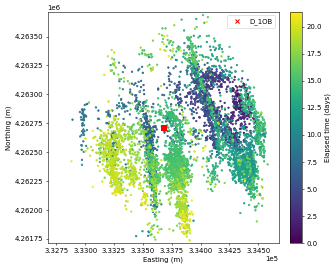

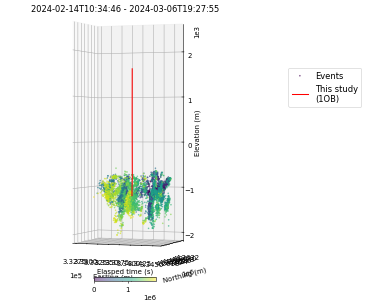

In [27]:
# =============================================================================
plot_events=True
# plot_events=False

# =============================================================================

# Read catalog
infile=os.path.join(opda_dir,'catalog','event_catalog.csv')
cat=pd.read_csv(infile)             
print('Columns in the catalog:')
print(cat.columns)
print('Number of events:',len(cat))

cat['easting']=cat.apply(lambda row: utm.from_latlon(row['lat'], row['lon'])[0],axis=1) 
cat['northing']=cat.apply(lambda row: utm.from_latlon(row['lat'], row['lon'])[1],axis=1)  
cat['evid']=cat.apply(lambda row: UTCDateTime(row['t0']).strftime('%Y%m%d%H%M%S_%f'),axis=1)

cat_t0_list=np.array([UTCDateTime(cat['t0'].values[i]) for i in range(len(cat))])
cat_elapsed_time_list=cat_t0_list-min(cat_t0_list)

cat_dep_list=cat['depth_m'].values
cat_UTMx_list=cat['easting'].values
cat_UTMy_list=cat['northing'].values
cat_lat_list=cat['lat'].values
cat_lon_list=cat['lon'].values
cat_ele_list=cat['elevation_m'].values

if plot_events:

    #% (Plot) MS and wells
    x=cat_UTMx_list
    y=cat_UTMy_list
    s=5
    c=cat_elapsed_time_list/86400
    fig=plt.figure(figsize=[10,6])
    
    ax = plt.gca()
    s1=ax.scatter(x,y,s=s,c=c)
    p1=ax.scatter(x_1OB,y_1OB,color='r',marker='x',label='D_1OB')
    plt.xlabel('Easting (m)')
    plt.ylabel('Northing (m)')
    ax.set_aspect('equal')
    
    ax.ticklabel_format(axis='both', style='sci',scilimits=(0,0))
    cbar=plt.colorbar(s1,ax=ax,pad=0.03)#,shrink=0.3,pad=0.1,aspect=8)
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label('Elapsed time (days)')
    colors=['b','yellow','magenta']
    plt.legend()#bbox_to_anchor=[1.8,0.5])
    ax.set_xlim(np.nanmedian(x_1OB)-1000,np.nanmedian(x_1OB)+1000)
    ax.set_ylim(np.nanmedian(y_1OB)-1000,np.nanmedian(y_1OB)+1000)
    
    plt.show()
    
    
    #%%%% (Plot) Wells & EQs
    
    # =============================================================================
    # xy_bdry=500
    z_bdy=1000
    equal_aspect=True
    # equal_aspect=False
    
    ch_num_1OB=1600 # The first dimension of 1OB data
    s=2
    
    # =============================================================================
    
    fig=plt.figure(figsize=[8,8])
    ax=plt.axes(projection='3d')
    
    x,y,z=cat_UTMx_list, cat_UTMy_list, cat_ele_list
    s1=ax.scatter(xs=x,ys=y,zs=z,s=s,label='Events',c=cat_elapsed_time_list,alpha=0.5)
    
    x1,y1,z1=x_1OB,y_1OB,z_1OB
    plt.plot(x1,y1,z1,label='This study\n(1OB)',color='r',zorder=5)
    plt.legend(bbox_to_anchor=[1.5,0.8],fontsize=12)
    
    ax.set_xlim(np.nanmin(x1)-1000,np.nanmax(x1)+1000)
    ax.set_ylim(np.nanmin(y1)-1000,np.nanmax(y1)+500)
    ax.set_zlim(np.nanmin(z1)-z_bdy,np.nanmax(z1)+z_bdy)
    plt.xlabel('Easting (m)')
    plt.ylabel('Northing (m)')
    ax.set_zlabel('Elevation (m)')
    # world_limits 
    # Equal aspect ratio
    if equal_aspect:
        world_limits = ax.get_w_lims()
        ax.set_box_aspect((world_limits[1]-world_limits[0],
                           world_limits[3]-world_limits[2],
                           world_limits[5]-world_limits[4]))
    
    ax.ticklabel_format(axis='both', style='sci',scilimits=(0,0))
    cbar=plt.colorbar(s1,ax=ax,pad=0.07,shrink=0.2,aspect=16,orientation='horizontal')
    cbar.ax.tick_params(labelsize=10)
    cbar.ax.set_title('Elasped time (s)',fontsize=10)
    # =============================================================================
    ax.view_init(0, 290, 0)
    
    # =============================================================================
    ax.set_title('%s - %s'%(min(cat_t0_list).strftime('%Y-%m-%dT%H:%M:%S'),
                            max(cat_t0_list).strftime('%Y-%m-%dT%H:%M:%S')))
    plt.show()


# Eikonal travel time (one event)

## Read event

In [6]:
# =============================================================================
iev=0 # Select one event 


# =============================================================================

In [7]:

# =============================================================================
# For loading the data
which_well='1OB'
# # Folder that contain the incident angles for each channels of each event 
# inc_angle_dir=os.path.join(opda_dir,'catalog','tt_inc_%s'%P_or_S)
# # Folder that contain the travel times for each channels of each event 
# tt_dir=os.path.join(opda_dir,'catalog','tt_inc_%s'%P_or_S)
# # Folder that contain the arrival picks for each channels of each event 
# arr_dir=os.path.join(opda_dir,'catalog','arr_picks_%s'%P_or_S)

# =============================================================================

In [8]:
# =============================================================================
show_plot=True

# =============================================================================
cat_target=cat.iloc[iev]                    # Target event catalog
t0=UTCDateTime(cat_target['t0'])                        # Origin time
evid=t0.strftime('%Y%m%d%H%M%S_%f') # evid is formatted using t0

#mag=cat_target['DAS_Mw']
cat_ele_list[iev]

# Event coordinates
elev_z_src=cat_target['elevation_m']
utm_x_src=cat_target['easting']
utm_y_src=cat_target['northing']
src_ch=rec_list[np.nanargmin(abs(elev_list-elev_z_src))] # Channel that is the closest to the source elevation

vec=np.stack([utmX_list,utmY_list,elev_list],axis=-1)-np.array([utm_x_src,utm_y_src,elev_z_src])
dis_m_list=np.linalg.norm(vec,axis=-1) # Straight line hypocentral distance 
chs_nan=np.where(np.isnan(dis_m_list))[0]
chs_valid=np.where(~np.isnan(dis_m_list))[0]

dep_src=(ref_elev-elev_z_src)
cat_dep_list=ref_elev-cat_ele_list


## Build the grid for ray tracing

[med, max] unc of dep for c: [2.8, 7.8] m
[med, max] unc of dep for ch depth: [1.2, 2.5] m


/tmp/ipykernel_4179400/3243557486.py:172: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks())


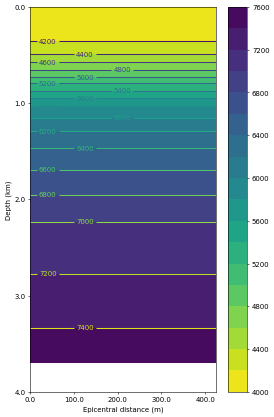

In [15]:
#%% Eikonal travel time (Cgrid, rec_izs, zaxis, xaxis)
# The grid need to be slightly larger than the source to receiver config.
# =============================================================================

P_or_S='P'

dx=5 # Mesh interval in both x and z direction

max_rec_z_unc= 20 # m # Maximum depth difference between channel and grid

show_plot=True # Plot the grid that we are calculating the ray tracing in

# =============================================================================


zmin=0
# zmax=np.ceil(dep_src/100)*100
zmax=np.ceil(np.max(cat_dep_list)/100)*100
zaxis=np.arange(zmin,zmax+dx,dx)
med_dis_H=np.linalg.norm([np.nanmedian(utmX_list)-utm_x_src,np.nanmedian(utmY_list)-utm_y_src],axis=-1)
xmax=med_dis_H
xaxis=np.arange(0,xmax+dx,dx)
# Initialize
Cgrid=np.zeros(shape=[len(zaxis),len(xaxis)])
c_z_uncs=np.full(len(zaxis),np.nan)
for iz, z in enumerate(zaxis):
    dep_diffs=np.abs(np.array(z-dep_for_vp_profile_closest))
    ind=np.nanargmin(dep_diffs)
    c_z_unc=dep_diffs[ind]
    # print('Depth difference between model and corresponding channel %.01f m'%(c_z_unc))
    
    vp=(vp_profile_closest_1OB[ind])
    Cgrid[iz,:]=vp
    c_z_uncs[iz]=dep_diffs[ind]
print('[med, max] unc of dep for c: [%.01f, %.01f] m'%(np.nanmedian(c_z_uncs),
                                                       np.nanmax(c_z_uncs)))
# Initialize
rec_izs=np.full(len(dep_ch_list),np.nan)
rec_z_uncs=np.full(len(dep_ch_list),np.nan)
for iz, z in enumerate(dep_ch_list):
    if ~np.isnan(z): 
        dep_diffs=np.abs(np.array(z-zaxis))
        ind=np.nanargmin(dep_diffs)
        rec_z_unc=dep_diffs[ind]
        # print('Depth difference between channel and corresponding grid %.01f m'%(rec_z_unc))
        if rec_z_unc<=max_rec_z_unc:
            rec_izs[iz]=ind
            rec_z_uncs[iz]=rec_z_unc
    
print('[med, max] unc of dep for ch depth: [%.01f, %.01f] m'%(
    np.nanmedian(rec_z_uncs),np.nanmax(rec_z_uncs)))

if show_plot:
    #%%% (Plot) Cgrid
    X,Z=np.meshgrid(xaxis,zaxis)
    fig,ax=plt.subplots(figsize=[6,10])
    c1=ax.contourf(X,Z,Cgrid,levels=20,cmap='viridis_r')
    CS=ax.contour(X,Z,Cgrid,levels=20)
    ax.clabel(CS, fontsize=10)
    
    ax.set_xlabel('Epicentral distance (m)')
    ax.set_ylabel('Depth (km)')
    # a
    cbar=fig.colorbar(c1)
    ax.set_xticklabels(ax.get_xticks())
    ax.set_yticks(ax.get_yticks()[::2],ax.get_yticks()[::2]/1000.)
    # plt.ylim(0,dep_src)
    ax.invert_yaxis()
    # ax.set_aspect('equal')
    plt.show()

## Run the ray tracing

In [13]:
#%%% Run

# =============================================================================
return_tt_matrix=True # Can turn it to False for travel time calculation to accelerate computation.

show_plot=True
# =============================================================================
        
tt_list,ray_path_list,rec_loc_list,tt_matrix = ut.get_tt_raypath_list(
    Cgrid,dx,xaxis,zaxis,dep_src,rec_izs,return_tt_matrix)

#%%% Incident angle
# Initialize
inc_angle_deg_list=np.full(len(ray_path_list),np.nan)

for i in range(len(ray_path_list)):
    ray_path=ray_path_list[i]
    if type(ray_path)!=float:
        vec=np.diff(ray_path[-2:,:],axis=0)[0] # [x,z,y]
        angle_rad=ut.angle_btw_vectors([vec[0],vec[2],vec[1]],[0,0,-1] )
        angle_deg=np.rad2deg(angle_rad)
        inc_angle_deg_list[i]=angle_deg
    # print('Incident angle: %.02f degree'%angle_deg)



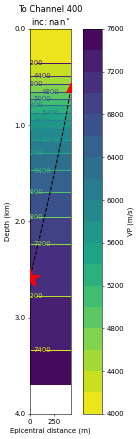

/tmp/ipykernel_4179400/326739627.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks())


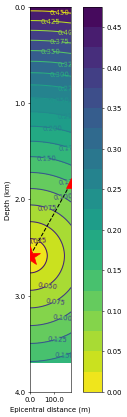

In [19]:
if show_plot:

    #%%% (Plot) Raypath in Vp grid
    # =============================================================================
    
    i=400 # Which channel to look at
    # i=800 
    # i=1200 
    
    # =============================================================================
    
    tt=tt_list[i]
    ray_path=ray_path_list[i]
    rec_loc=rec_loc_list[i]
    angle_deg=inc_angle_deg_list[i]
    X,Z=np.meshgrid(xaxis,zaxis)
    fig,ax=plt.subplots(figsize=[6,10])
    c1=ax.contourf(X,Z,Cgrid,levels=20,cmap='viridis_r')
    CS=ax.contour(X,Z,Cgrid,levels=20)
    
    ax.clabel(CS, fontsize=10)
    ax.plot(0,dep_src,marker='*',color='r',zorder=5,ms=30)
    ax.plot(rec_loc[0],rec_loc[1],marker='^',color='r',zorder=5,ms=15)
    ax.plot(ray_path[:,0],ray_path[:,1],ls='dashed',color='k',ms=30)
    ax.set_title('To Channel %s'%i+'\n'+'inc: %.01f$^\circ$'%angle_deg)
    ax.set_xlabel('Epicentral distance (m)')
    ax.set_ylabel('Depth (km)')
    # ax.set_xticklabels(ax.get_xticks())
    ax.set_aspect('equal')
    cbar=fig.colorbar(c1)
    
    # ax.set_yticklabels(ax.get_yticks()/1000.)
    ax.set_yticks(ax.get_yticks()[::2],ax.get_yticks()[::2]/1000.)
    cbar.ax.set_ylabel('V%s (m/s)'%P_or_S)
    # plt.ylim(0,dep_src)
    ax.invert_yaxis()
    plt.show()

    #%%% (Plot) Raypath in tt_matrix
    # =============================================================================
    i=1000 # Which channel
    
    # =============================================================================
    tt=tt_list[i]
    ray_path=ray_path_list[i]
    rec_loc=rec_loc_list[i]
    
    X,Z=np.meshgrid(xaxis,zaxis)
    fig,ax=plt.subplots(figsize=[6,10])
    c1=ax.contourf(X,Z,tt_matrix[:,:,0].T,levels=20,cmap='viridis_r')
    CS=ax.contour(X,Z,tt_matrix[:,:,0].T,levels=20)
    ax.clabel(CS, fontsize=10)
    
    
    ax.plot(0,dep_src,marker='*',color='r',zorder=5,ms=30)
    ax.plot(rec_loc[0],rec_loc[1],marker='^',color='r',zorder=5,ms=15)
    ax.plot(ray_path[:,0],ray_path[:,1],ls='dashed',color='k',ms=30)
    
    ax.set_xlabel('Epicentral distance (m)')
    ax.set_ylabel('Depth (km)')
    ax.set_aspect('equal')
    cbar=fig.colorbar(c1)
    ax.set_xticklabels(ax.get_xticks())
    # ax.set_yticklabels(ax.get_yticks()/1000.)
    ax.set_yticks(ax.get_yticks()[::2],ax.get_yticks()[::2]/1000.)
    # plt.ylim(0,dep_src)
    ax.invert_yaxis()
    plt.show()

## Save travel time and incident angles

In [22]:

# =============================================================================
inc_angle_dir=os.path.join(opda_dir,'catalog','tt_inc_%s'%P_or_S)
# Folder that contain the travel times for each channels of each event 
tt_dir=os.path.join(opda_dir,'catalog','tt_inc_%s'%P_or_S)


overwrite=False
# =============================================================================

save_filename=os.path.join(tt_dir,'travel_times_%s_well%s_id%s.npy'%(P_or_S,which_well,evid))
save_filename_inc_angle=os.path.join(inc_angle_dir,'inc_angles_rad_%s_well%s_id%s.npy'%(P_or_S,which_well,evid))

if os.path.exists(save_filename) and overwrite==False:
    print('Passing existing file.')
    pass
else:
    np.save(save_filename,tt_list,
             allow_pickle=True)
    print('Saved as',save_filename)
    
if os.path.exists(save_filename_inc_angle) and overwrite==False:
    print('Passing existing file.')
    pass
else:

    
    np.save(save_filename_inc_angle,inc_angle_rad_list,
             allow_pickle=True)
    print('Saved as',save_filename_inc_angle)

# Accumulated attenuation based on Eikonal travel time and Q (one event)
This part require the Q profile from f400. Check that notebook to see how I produce the Q profile.
Make sure you have Q_profile_P_1OB_events_fit20-200Hz.npz is models/, and then run 1. 2.(with return_tt_matrix=True) first before running this part.

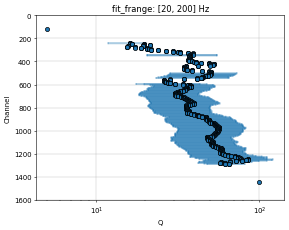

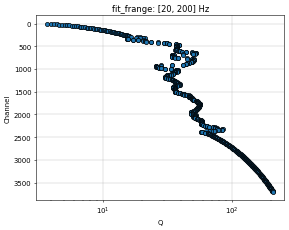

In [29]:
#%%% Attenuation for channels
assert return_tt_matrix==True, "I need tt_matrix to estimate attenuation. Rerun 2. with return_tt_matrix=True"


# =============================================================================

# For loading the Q profile I saved using f400
fit_frange=[20,200]

# Minimum elevation of the Q profile. Q measurements at lower elevation will be 
# discarded. This is a quick way to discard Q measured by P waves with large 
# incident angles and too close to the source region.
min_att_elev=-800 # I checked that below this elevation, Q might be less reliable.

# Interpolate Q shallower and deeper than the results
# These numbers should result in the minimum channel-dependence of source parameters
shallow_Q=5
deep_Q=100

show_plot=True
# =============================================================================

# Qsite profile
load_dir=os.path.join(opda_dir,'models')
infile=os.path.join(load_dir,'Q_profile_%s_%s_events_fit%d-%dHz.npz'%(P_or_S,which_well,fit_frange[0],fit_frange[1]))
r=np.load(infile)
med_Q_chs=r['med_Q_chs']
mad_Q_chs=r['mad_Q_chs']
ind1=np.where(np.array(elev_list)<min_att_elev)[0] 
med_Q_chs[ind1]=np.nan
mad_Q_chs[ind1]=np.nan
ind_good=np.where(~np.isnan(med_Q_chs))[0]

if ind_good[0]>0: 
    # med_Q_chs[:ind_good[0]]=shallow_Q
    med_Q_chs[ind_good[0]//2]=shallow_Q
if ind_good[-1]< len(med_Q_chs)-1:
    med_Q_chs[int(ind_good[-1]+(len(med_Q_chs)-ind_good[-1])/2)]=deep_Q
    
if show_plot:
    fig,ax=plt.subplots()
    x2=med_Q_chs
    y2=np.arange(len(x2))
    xerr=mad_Q_chs
    ax.scatter(x2,y2,zorder=3,edgecolor='k')
    ax.errorbar(x2, y2, xerr=xerr,capsize=1,lw=0,ms=0,capthick=0.3,color='tab:blue',elinewidth=0.5,alpha=0.5)
    ax.set_ylabel('Channel')
    ax.set_xlabel('Q')
    ax.set_xscale('log')
    ax.invert_yaxis()
    ax.set_ylim([1600,0])
    ax.grid(True,lw=0.5)
    ax.set_title('fit_frange: %s Hz'%(fit_frange))
    plt.show()

#%%%% Interpolate to grid
ind=np.where(~np.isnan(med_Q_chs))[0]
interp_Q_dep_func= interp1d(dep_ch_list[ind],med_Q_chs[ind], 
                             kind='linear', fill_value='extrapolate')

Q_dep_profile=interp_Q_dep_func(zaxis) # This is the 1D Q corresponding to the grid points.

if show_plot:
    fig,ax=plt.subplots()
    x2=Q_dep_profile
    y2=zaxis
    # xerr=mad_Q_chs
    ax.scatter(x2,y2,zorder=3,edgecolor='k')
    # ax.errorbar(x2, y2, xerr=xerr,capsize=1,lw=0,ms=0,capthick=0.3,color='tab:blue',elinewidth=0.5,alpha=0.5)
    ax.set_ylabel('Channel')
    ax.set_xlabel('Q')
    ax.set_xscale('log')
    ax.invert_yaxis()
    # ax.set_ylim([1600,0])
    ax.grid(True,lw=0.5)
    ax.set_title('fit_frange: %s Hz'%(fit_frange))
    plt.show()


## Calculate accumulated attenuation

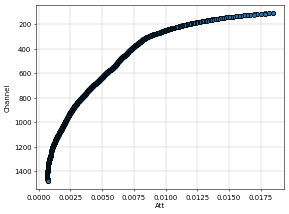

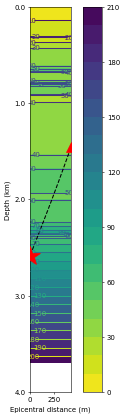

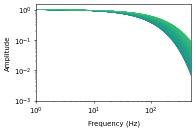

In [34]:
# =============================================================================
show_plot=True

# =============================================================================
#%%%% Calculate attnuation of channels
att_list=ut.get_att_along_path_list(Qgrid_z=Q_dep_profile,tt_matrix=tt_matrix,
                       ray_path_list=ray_path_list,xaxis=xaxis,zaxis=zaxis)

if show_plot:
    # (Plot) Accumulated attenuation (each channel)
    fig,ax=plt.subplots()
    x2=att_list
    y2=np.arange(len(x2))
    ax.scatter(x2,y2,zorder=3,edgecolor='k')
    ax.set_ylabel('Channel')
    ax.set_xlabel('Att')
    # ax.set_xscale('log')
    ax.invert_yaxis()
    # ax.set_ylim([1600,0])
    ax.grid(True,lw=0.5)
    # ax.set_title('fit_frange: %s Hz'%(fit_frange))
    plt.show()


    #%%%% (Plot) Raypath in Q grid
    # =============================================================================
    i=820 # Which channel to plot
    
    # =============================================================================
    
    ray_path.shape
    
    tt=tt_list[i]
    ray_path=ray_path_list[i]
    rec_loc=rec_loc_list[i]
    X,Z=np.meshgrid(xaxis,zaxis)
    fig,ax=plt.subplots(figsize=[6,10])
    
    
    c1=ax.contourf(X,Z,np.tile(Q_dep_profile, (len(xaxis),1)).T,levels=20,cmap='viridis_r')
    CS=ax.contour(X,Z,np.tile(Q_dep_profile, (len(xaxis),1)).T,levels=20)
    
    ax.clabel(CS, fontsize=10)
    ax.plot(0,dep_src,marker='*',color='r',zorder=5,ms=30)
    ax.plot(rec_loc[0],rec_loc[1],marker='^',color='r',zorder=5,ms=15)
    ax.plot(ray_path[:,0],ray_path[:,1],ls='dashed',color='k',ms=30)
    
    ax.set_xlabel('Epicentral distance (m)')
    ax.set_ylabel('Depth (km)')
    ax.set_aspect('equal')
    cbar=fig.colorbar(c1)
    # ax.set_xticklabels(ax.get_xticks())
    # ax.set_yticklabels(ax.get_yticks()/1000.)
    ax.set_yticks(ax.get_yticks()[::2],ax.get_yticks()[::2]/1000.)
    # plt.ylim(0,dep_src)
    ax.invert_yaxis()
    plt.show()
    

    #%%%% (Plot) Accumulated attenuation (amplitude)
    x=np.logspace(0,np.log10(500))
    # ymin,ymax=1,1000
    ymin,ymax=None,None
    # ax.get_ylim()
    colormap = plt.cm.viridis
    colorst = [colormap(i/len(att_list)) for i in range(len(att_list))]
    
    fig, ax = plt.subplots(figsize=[4,2.5])
    for i in range(len(att_list)):
        # if i%5==0: 
        if i>820 and i<1100:
        # if True:
            y=np.exp(-np.pi*x*att_list[i])
            #print(att_list[i])
            
            plt.loglog(x, y, linewidth=0.5,color=colorst[i])
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Amplitude')
    plt.xlim(1,500)
    plt.ylim(0.001,1.5)
    plt.show()

## Save accumulated attenuation

In [39]:
# =============================================================================
att_dir=os.path.join(opda_dir,'catalog','accum_att_%s'%P_or_S)
overwrite=False
# =============================================================================
save_filename=os.path.join(att_dir,'accum_att_%s_well%s_id%s.npy'%(P_or_S,which_well,evid))

if os.path.exists(save_filename) and overwrite==False:
    print('Passing existing file.')
    pass
else:
    np.save(save_filename,att_list,allow_pickle=True)
    print('Saved as',save_filename)

Passing existing file.


After saving accumulated attenuation, we can run single-spectra fitting in f500.